# Process Integrated Budget Survey Training Data 

This notebook carries out carries out a series of processing steps in order to create proper training data using the Integrated Budget Survey data to reconstruct SHA's means testing model. Aligning variables with those listed in SHA's FOI response, including dummifying, calculating new variables, and cleaning others.

Author: Purity Mukami 

In [49]:
import pandas as pd
import numpy as np 
from pathlib import Path
import sys 


PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

from config import paths 
from util.normalize_column_name import normalize_column_name

### Reading in the all the relevant datasets

KNBS splits datasets into different categories, all of which can be joined via a household ID. Our wrangling scripts perform a series of preprocessing steps 

In [50]:
df_individual_microdata = pd.read_csv(paths.INTERMEDIATE_DATA / "knbs_ibs_2015/ibs_2015_individuals.csv", low_memory=False)
df_household_microdata = pd.read_csv(paths.INTERMEDIATE_DATA / "knbs_ibs_2015/ibs_2015_households.csv", low_memory=False)
df_nonfood_microdata = pd.read_csv(paths.INTERMEDIATE_DATA / "knbs_ibs_2015/ibs_2015_nonfood.csv", low_memory=False)
df_assets_microdata = pd.read_csv(paths.INTERMEDIATE_DATA / "knbs_ibs_2015/ibs_2015_assets.csv", low_memory=False)
df_consumption_microdata = pd.read_csv(paths.INTERMEDIATE_DATA / "knbs_ibs_2015/ibs_2015_consumption.csv", low_memory=False)
df_land_microdata = pd.read_csv(paths.INTERMEDIATE_DATA / 'knbs_ibs_2015/ibs_2015_land.csv')


###  Computing  the variables matching with FIOA Response PMT questions from the  kchs_21 individual dataset 
 
Unlike all the other datasets, which exist at the household level, the individual dataset as at the individual level. Varoius PMT variables, such as *mm_age* are aggregates of individual-level characteristics, while others, like *education_level* are based on the characteristics of the household head. 

Below, we calculate these various variables

In [51]:
"""
HOUSEHOLD-WIDE AGGREGATES from the individual level data
We use .transform() to calculate values across the whole household group instantly
Also we will Use transform('mean') on the masks grouped by hhid. This calculates the household average and maps it back to every row automatically
"""

df = df_individual_microdata.copy()
hh_groups = df.groupby("unique_id")

# Demographic proportions (Age)
df['age_years'] = 2026 - df['date_of_birth_year']
df["prop_over65"] = hh_groups["age_years"].transform(lambda x: (x >= 65).mean())
df["prop_under5"] = hh_groups["age_years"].transform(lambda x: (x <= 5).mean())
df["mm_age"] = np.log(hh_groups["age_years"].transform("sum") + 1e-6)

# Demographic proportions (M/W 18-64)
is_m1864 = (df["sex"] == "Male") & df["age_years"].between(18, 64)
is_w1864 = (df["sex"] == "Female") & df["age_years"].between(18, 64)

# Household-wide proportion using transform directly on the mask
df["prop_m1864"] = is_m1864.groupby(df["unique_id"]).transform("mean")
df["prop_w1864"] = is_w1864.groupby(df["unique_id"]).transform("mean")
df['num_children'] = hh_groups["age_years"].transform(lambda x: x.between(0, 17).sum())

#### Household Head Variables 

In [52]:
""" 
HOUSEHOLD HEAD VARIABLES 
Identify the Head row
"""

is_head = df["relationship"] == 'Head'

#Creating the occupation/status variables specifically from the Head's data Using np.where, the vectorized equivalent of "if any... else" logic 
df.loc[is_head, "d01_own_account"] = np.where(
    df.loc[is_head, "activity_status_time_primary"] == "Own-account worker", "Yes", "No"
)
df.loc[is_head, "d01_wage"] = np.where(
    df.loc[is_head, "activity_status_time_primary"] == "Paid employee (outside hh )", "Yes", "No"
)
df.loc[is_head, "d01_own_frm"] = np.where(
    df.loc[is_head, "main_employer_primary_job"] == " Self small scale agriculture", "Yes", "No"
)

# We extract the Head's specific values into a mapping dictionary. This is the the process of taking information that belongs to one specific person (the Household Head) and "copying and pasting" it onto every other person living in that same house.
head_rows = df[is_head].set_index('unique_id')

df.loc[is_head, "hhhead_sex"] = df.loc[is_head, "unique_id"].map(head_rows['sex'])
df.loc[is_head, "age_household_head"] = df.loc[is_head, "unique_id"].map(head_rows['age_years'])
df.loc[is_head, "hhhead_marital"] = df.loc[is_head, "unique_id"].map(head_rows['marital_status'])
df.loc[is_head, "hhhead_education"] = df.loc[is_head, "unique_id"].map(head_rows['education_level'])
working_map = ~head_rows['activity_status_time_primary'].isna()
df.loc[is_head, "hhhead_working"] = (df.loc[is_head, "unique_id"].map(working_map).fillna(False))

filtered_df_individual_microdata = df[is_head].copy().reset_index(drop=True)

#### Adding the "occupation" variable to the above filtered dataset 

The PMT model contains a complicated variable on occupation, which based on the possible responses is actually a combination of various other fields in the labor section of the individual household data. The criterion for this can be seen below. 

In [53]:
#Picking up from the previous filtered dataset we start by defining the LOGICAL CONDITIONS (9 total)
final_filtered_df_individual_microdata = filtered_df_individual_microdata 

Criteria = [
    # 1. Public sector
    final_filtered_df_individual_microdata["main_employer_primary_job"].str.contains("Government|school|state|civil|judiciary|parliament|commission", case=False, na=False),
    
    # 2. Farmer
    final_filtered_df_individual_microdata["primary_occupation_knocs"].str.contains("farmer|farming|SUBSISTENCE", case=False, na=False)|
    (final_filtered_df_individual_microdata["main_employer_primary_job"] == " Self small scale agriculture"),

    # 3. Private sector
    final_filtered_df_individual_microdata["main_employer_primary_job"].str.contains("PRIVATE SECTOR|NGO|FAITH BASED ORGANIZATION", case=False, na=False ),
    
    # 4. Business lady/man
    final_filtered_df_individual_microdata["main_employer_primary_job"].str.contains("SELF EMPLOYED|SELF MODERN", case=False, na=False ),
    
    # 5. Housewife
    final_filtered_df_individual_microdata["main_reason_not_looking_for_work"] == "Housewife/family responsibilities",
    
    # 6. Artisan/self-employed
    (final_filtered_df_individual_microdata["activity_status_time_primary"] == "Own-account worker")|
    (final_filtered_df_individual_microdata["primary_occupation_knocs"].str.contains("artisan|tailor|carpenter|mason|mechanic|welder|plumber|painter|weaver",case=False, na=False)),
    
    # 7. Retired
    final_filtered_df_individual_microdata["main_reason_not_looking_for_work"] == "Retired/income recipient",
    
    # 8. Housekeeper
    final_filtered_df_individual_microdata["primary_occupation_knocs"].str.contains(" Cleaners Launders and Domestic Workers|" \
    "House Stewards", case=False, na=False ),

    # 9. Casual labour
    (final_filtered_df_individual_microdata["primary_activity_working_pattern"] == "Casual worker")
]

category = [
    "Public sector worker",    
    "Farmer",                  
    "Private sector worker",  
    "Business lady/man",      
    "Housewife",                    
    "Artisan/self-employed",   
    "Retired",                 
    "Housekeeper",             
    "Casual labour"            
]

# np.select will now see exactly 9 conditions and 9 choices 
final_filtered_df_individual_microdata["occupation"] = np.select(Criteria, category, default="Other, specify")


### Merging all the  datsets at household level

This is based on 'unqiue_id'

In [54]:
original_length = len(df_household_microdata)

merged_df = pd.merge(final_filtered_df_individual_microdata, df_household_microdata, on= 'unique_id', how= 'right', suffixes=(None, '_household'))
merged_df = pd.merge(merged_df, df_nonfood_microdata, on='unique_id', how = 'left', suffixes=(None, '_nonfood'))
merged_df = pd.merge(merged_df, df_assets_microdata, on='unique_id', how = 'left', suffixes=(None, '_nonfoodknp'))
merged_df = pd.merge(merged_df, df_land_microdata, on='unique_id', how = 'left', suffixes=(None, '_land'))
merged_df = pd.merge(merged_df, df_consumption_microdata, on='unique_id', how='left', suffixes=(None, '_consumption'))

merged_df = merged_df.reset_index(drop=True)

# Assert that merge has occured correctly. 
assert len(merged_df) == original_length, "Merging altered the number of households!"

merged_df.head()

,cluster_id,household_id,line_number,relationship,Unnamed: 4,sex,age_in_months,date_of_birth_day,date_of_birth_month,date_of_birth_year,...,monthly_per_adult_equivalent_rent_consumption_expenditure_deflated__urban_onl,monthly_per_adult_equivalent_energy_consumption_expenditure_deflated,monthly_per_adult_equivalent_total_consumption_expenditure_deflated,monthly_per_adult_equivalent_food_expenditure_deflated,absolute_poverty_line_using_food_poverty_line_and_ravallion_method_lower_bound,food_poverty_line,household_level_price_deflator,household_weight_consumption,population_weighting_coefficient,adult_equivalent_population_weighting_coefficient
0,140.0,1,1,Head,NaN,Male,NaN,1.0,1.0,1975.0,...,785.20060,226.83572,10294.8740,3371.7310,5995.902,2551.1006,0.996699,761.230824,2283.69240,1750.83080
1,140.0,2,1,Head,NaN,Male,NaN,25.0,12.0,1988.0,...,583.14777,322.97415,6330.5884,3123.4250,5995.902,2551.1006,0.995215,761.230824,2283.69240,1705.15700
2,140.0,3,1,Head,NaN,Male,NaN,15.0,8.0,1986.0,...,676.95010,77.36572,11615.3545,10498.3870,5995.902,2551.1006,1.034050,761.230824,761.23083,761.23083
3,140.0,4,1,Head,NaN,Male,NaN,22.0,6.0,1976.0,...,398.24042,537.62460,7073.1494,3788.1343,5995.902,2551.1006,1.004418,761.230824,1522.46170,1522.46170
4,140.0,5,1,Head,NaN,Male,NaN,4.0,11.0,1989.0,...,497.14285,323.97144,3895.0674,1748.5841,5995.902,2551.1006,1.077586,761.230824,2283.69240,1705.15700


#### Create access to electricity 

Messy columnw ehre N/As shoudl be yes. 

In [55]:
merged_df['access_electricity'] = merged_df['access_electricity'].fillna('Yes')
merged_df['access_electricity'].value_counts()

access_electricity
No     14297
Yes     7476
Name: count, dtype: int64

#### Fix radio column, which has two different item codes 

In [56]:
merged_df['own_radio'] = np.where(
    (merged_df['own_radio'] == 'Yes') | (merged_df['owns_9501'] == 'Yes'),
    'Yes',
    'No'
)

#### Load in variables 

We load in the set of variables included on the PMT form from an external spreadsheet. 

In [57]:
# We start by reading the tab that has all the mapping in a xls file
IBS_2015_PMT_VARIABLES = pd.read_excel(paths.CONFIG / 'pmt_variables.xlsx', sheet_name='ibs_2015_pmt_variables')

IBS_2015_PMT_VARIABLES.head()

,FOI,Rename,IBS current
0,County,County,county
1,household_size,household_size,total_persons_in_household
2,hhhead_sex,sex,sex
3,hhhead_working,did_not_work,even_though_name_did_not_do_any_of_these_activ...
4,marital_status,marital_status,what_is_names_marital_status


#### Rename label and create a filtered version of the training data 

In [58]:
# Rename our label and set unique id as index. Add abs_poor column 
merged_df['padqexp'] = merged_df['monthly_per_adult_equivalent_total_consumption_expenditure_deflated']

merged_df['abs_poor'] = merged_df['padqexp'] <= merged_df['absolute_poverty_line_using_food_poverty_line_and_ravallion_method_lower_bound']
merged_df['food_poor'] = merged_df['padqexp'] <= merged_df['food_poverty_line']

training_data_all = merged_df

foi_pmt_variables = IBS_2015_PMT_VARIABLES['FOI'].to_list()
foi_pmt_variables = list(dict.fromkeys(foi_pmt_variables)) # Remove duplicates 

# Create the list from Excel and add our two extra variables in one go
foi_pmt_variables = foi_pmt_variables + ['padqexp'] # We add these two 
training_data_filtered = merged_df[foi_pmt_variables]

training_data_filtered.head()


,County,household_size,hhhead_sex,hhhead_working,marital_status,education_level,dwelling,nr_rooms,ownership_dwelling,tenure_status,...,land_size,productive_land,urban_rural_classification,mm_age,prop_over65,prop_under5,prop_m1864,prop_w1864,unique_id,padqexp
0,Mombasa,3,Male,True,Never married,Primary,Swahili,1.0,Pays Rent/Lease,NaN,...,0.0,0.0,Urban,4.488636,0.0,0.0,0.666667,0.333333,140_1,10294.8740
1,Mombasa,3,Male,True,Living together,Secondary,Swahili,1.0,Pays Rent/Lease,NaN,...,0.0,0.0,Urban,4.532600,0.0,0.0,0.333333,0.333333,140_2,6330.5884
2,Mombasa,1,Male,True,Never married,Primary,Swahili,1.0,Pays Rent/Lease,NaN,...,0.0,0.0,Urban,3.688879,0.0,0.0,1.000000,0.000000,140_3,11615.3545
3,Mombasa,2,Male,True,Monogamous married,Primary,Swahili,1.0,Pays Rent/Lease,NaN,...,0.0,0.0,Urban,4.406719,0.0,0.0,1.000000,0.000000,140_4,7073.1494
4,Mombasa,3,Male,True,Monogamous married,Primary,Swahili,1.0,Pays Rent/Lease,NaN,...,0.0,0.0,Urban,4.430817,0.0,0.0,0.333333,0.333333,140_5,3895.0674


### Dummify categorical variables 

In [59]:
categorical_cols = training_data_filtered.select_dtypes(include='object').columns.tolist()

# Create a new list that EXCLUDES the classification column
cols_to_dummy = [col for col in categorical_cols if col != 'urban_rural_classification' and col != 'unique_id']

# 3. Now run get_dummies only on the filtered list
training_data_filtered_with_dummies = pd.get_dummies(training_data_filtered, columns=cols_to_dummy, drop_first=True)

training_data_filtered_with_dummies

,household_size,nr_rooms,land_size,productive_land,urban_rural_classification,mm_age,prop_over65,prop_under5,prop_m1864,prop_w1864,...,d01_own_frm_Yes,occupation_Business lady/man,occupation_Casual labour,occupation_Farmer,occupation_Housekeeper,occupation_Housewife,"occupation_Other, specify",occupation_Private sector worker,occupation_Public sector worker,occupation_Retired
0,3,1.0,0.0,0.0,Urban,4.488636,0.0,0.0,0.666667,0.333333,...,False,False,False,False,False,False,False,True,False,False
1,3,1.0,0.0,0.0,Urban,4.532600,0.0,0.0,0.333333,0.333333,...,False,False,False,False,False,False,False,True,False,False
2,1,1.0,0.0,0.0,Urban,3.688879,0.0,0.0,1.000000,0.000000,...,False,False,False,False,False,False,False,True,False,False
3,2,1.0,0.0,0.0,Urban,4.406719,0.0,0.0,1.000000,0.000000,...,False,False,False,False,False,False,False,True,False,False
4,3,1.0,0.0,0.0,Urban,4.430817,0.0,0.0,0.333333,0.333333,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21768,1,1.0,0.0,0.0,Urban,3.637586,0.0,0.0,0.000000,1.000000,...,False,False,False,False,False,False,False,False,True,False
21769,3,1.0,0.0,0.0,Urban,4.499810,0.0,0.0,0.666667,0.333333,...,False,True,False,False,False,False,False,False,False,False
21770,2,1.0,5.0,5.0,Urban,4.304065,0.0,0.0,1.000000,0.000000,...,False,False,False,False,False,False,False,True,False,False
21771,8,1.0,0.0,0.0,Urban,5.488938,0.0,0.0,0.500000,0.500000,...,False,False,False,False,False,False,True,False,False,False


#### Convert True and False columns in the merged file to 0s and 1s

In [60]:
bool_cols = training_data_filtered_with_dummies.select_dtypes(include='bool').columns 
training_data_filtered_with_dummies[bool_cols] = training_data_filtered_with_dummies[bool_cols].astype(int)

#### Normalize column names and dropna 

In [61]:
training_data_filtered_with_dummies.columns = training_data_filtered_with_dummies.columns.map(normalize_column_name)
training_data_filtered_with_dummies = training_data_filtered_with_dummies.dropna()

training_data_filtered_with_dummies

,household_size,nr_rooms,land_size,productive_land,urban_rural_classification,mm_age,prop_over65,prop_under5,prop_m1864,prop_w1864,...,d1_own_frm_yes,occupation_business_lady_man,occupation_casual_labour,occupation_farmer,occupation_housekeeper,occupation_housewife,occupation_other_specify,occupation_private_sector_worker,occupation_public_sector_worker,occupation_retired
0,3,1.0,0.0,0.0,Urban,4.488636,0.0,0.0,0.666667,0.333333,...,0,0,0,0,0,0,0,1,0,0
1,3,1.0,0.0,0.0,Urban,4.532600,0.0,0.0,0.333333,0.333333,...,0,0,0,0,0,0,0,1,0,0
2,1,1.0,0.0,0.0,Urban,3.688879,0.0,0.0,1.000000,0.000000,...,0,0,0,0,0,0,0,1,0,0
3,2,1.0,0.0,0.0,Urban,4.406719,0.0,0.0,1.000000,0.000000,...,0,0,0,0,0,0,0,1,0,0
4,3,1.0,0.0,0.0,Urban,4.430817,0.0,0.0,0.333333,0.333333,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21768,1,1.0,0.0,0.0,Urban,3.637586,0.0,0.0,0.000000,1.000000,...,0,0,0,0,0,0,0,0,1,0
21769,3,1.0,0.0,0.0,Urban,4.499810,0.0,0.0,0.666667,0.333333,...,0,1,0,0,0,0,0,0,0,0
21770,2,1.0,5.0,5.0,Urban,4.304065,0.0,0.0,1.000000,0.000000,...,0,0,0,0,0,0,0,1,0,0
21771,8,1.0,0.0,0.0,Urban,5.488938,0.0,0.0,0.500000,0.500000,...,0,0,0,0,0,0,1,0,0,0


#### Create a log version of consumption 

/var/folders/hp/kn6pmy_14nv6djdz1m3qrg200000gn/T/ipykernel_89375/2663023034.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  training_data_filtered_with_dummies['actual_consumption_log'] = np.log(training_data_filtered['padqexp'])
/var/folders/hp/kn6pmy_14nv6djdz1m3qrg200000gn/T/ipykernel_89375/2663023034.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  training_data_filtered_with_dummies['actual_consumption_log'] = np.log(training_data_filtered['padqexp'])


<Axes: >

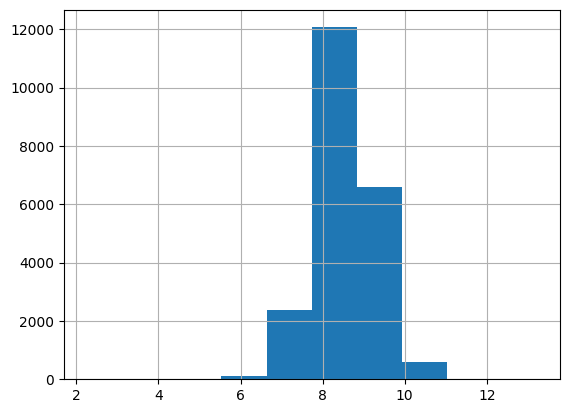

In [62]:
training_data_filtered_with_dummies['actual_consumption_log'] = np.log(training_data_filtered['padqexp'])
training_data_filtered_with_dummies = training_data_filtered_with_dummies.drop(columns=['padqexp'])
training_data_filtered_with_dummies['actual_consumption_log'].hist()

In [63]:
training_data_filtered_with_dummies.head(3)

,household_size,nr_rooms,land_size,productive_land,urban_rural_classification,mm_age,prop_over65,prop_under5,prop_m1864,prop_w1864,...,occupation_business_lady_man,occupation_casual_labour,occupation_farmer,occupation_housekeeper,occupation_housewife,occupation_other_specify,occupation_private_sector_worker,occupation_public_sector_worker,occupation_retired,actual_consumption_log
0,3,1.0,0.0,0.0,Urban,4.488636,0.0,0.0,0.666667,0.333333,...,0,0,0,0,0,0,1,0,0,9.239401
1,3,1.0,0.0,0.0,Urban,4.532600,0.0,0.0,0.333333,0.333333,...,0,0,0,0,0,0,1,0,0,8.753148
2,1,1.0,0.0,0.0,Urban,3.688879,0.0,0.0,1.000000,0.000000,...,0,0,0,0,0,0,1,0,0,9.360083


#### Save everything 

In [64]:
training_data_filtered_with_dummies.to_csv(paths.PROCESSED_DATA / "td_ibs_2015_filtered.csv", index=False)

training_data_all = training_data_all.merge(training_data_filtered_with_dummies, on='unique_id', how='left', suffixes=(None, '_all'))
training_data_all.to_csv(paths.PROCESSED_DATA / "td_ibs_2015_all.csv", index=False)